# 05 - Forecasting and predictive maintenance (SYNTHETIC)
ARIMA is not included (statsmodels unavailable); an OLS autoregression is used as a labelled alternative.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30); pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
from og_oip import config
NOTICE = config.SYNTHETIC_NOTICE
print(NOTICE)

All operational, production, financial, maintenance, inventory, sensor and HSE data in this project are synthetic/simulated and created for portfolio demonstration purposes. They do not represent actual operations of a real company.


In [2]:
from og_oip.forecasting import models as fmod
t_prod = pd.read_csv(config.PROCESSED_DIR / "fact_production.csv", parse_dates=["date"])
ser = t_prod.groupby("date")["oil_production_bbl"].sum().asfreq("D")
det, summ = fmod.backtest(ser); summ

                           model      MAE     RMSE  MAPE_pct  mean_bias  origins
2           Moving average (30d)   942.65 1,162.62      8.06     263.79        6
3            Moving average (7d)   965.83 1,176.41      8.15      25.33        6
5   Simple exponential smoothing 1,083.75 1,312.92      9.02     -52.48        6
1  Damped Holt (trend) smoothing 1,084.49 1,313.69      9.03     -53.21        6
0       Autoregression AR(7) OLS 1,167.46 1,434.39     10.07     929.14        6
4             Naive (last value) 1,351.53 1,617.52     11.16     -91.70        6

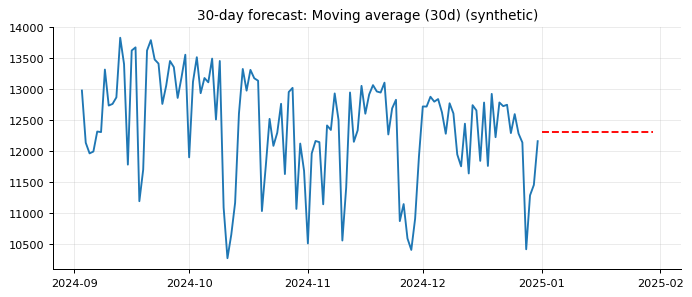

In [3]:
best = summ.iloc[0].model; fc = fmod.final_forecast(ser, best, 30)
fig, ax = plt.subplots(figsize=(9,3.5)); ax.plot(ser.index[-120:], ser.values[-120:]); ax.plot(fc.date, fc.forecast_oil_bbl, "r--"); ax.set_title(f"30-day forecast: {best} (synthetic)"); plt.show()

Backtests are rolling-origin (6 origins, 30-day horizon). New wells create level shifts no baseline can anticipate.

## Predictive maintenance: 7-day failure risk

In [4]:
from og_oip.ml import predictive_maintenance as pm
sd = pd.read_csv(config.MARTS_DIR / "mart_sensor_daily.csv", parse_dates=["date"]); maint = pd.read_csv(config.PROCESSED_DIR / "fact_maintenance.csv", parse_dates=["date"])
eq = pd.read_csv(config.PROCESSED_DIR / "dim_equipment.csv", parse_dates=["installation_date"])
d = pm.build_dataset(sd, maint, eq); print(d.shape, "positive rate %:", round(100*d.label.mean(),2))
res, info, fitted, (tr, va, te), scores = pm.run_experiment(d); info

(50880, 34) positive rate %: 5.38


{'train_rows': 17280, 'val_rows': 7200, 'test_rows': 25392, 'train_positive_rate_pct': np.float64(4.855324074074074), 'test_positive_rate_pct': np.float64(5.797101449275362), 'test_failure_events_positive_rows': 1472, 'split': {'train_end': '2023-01-31', 'val_end': '2023-06-30', 'test_start': '2023-07-15', 'test_end': '2024-12-24'}, 'note': 'Positive-rate baseline: PR-AUC of a random model equals the test positive rate.'}

In [5]:
res.round(3)

                                  model  roc_auc  pr_auc  precision  recall   f1  threshold   tp   fp   fn     tn
0                   Logistic Regression     0.81    0.46       0.62    0.42 0.50       0.80  620  386  852  23534
1                         Random Forest     0.80    0.50       0.71    0.46 0.56       0.54  673  280  799  23640
2            Gradient Boosting (HistGB)     0.78    0.45       0.63    0.40 0.49       0.35  588  345  884  23575
3  Rule baseline: 3-day vibration ratio     0.75    0.38       0.65    0.39 0.49       1.16  578  318  894  23602

In [6]:
best_row = res.iloc[:3].sort_values("pr_auc", ascending=False).iloc[0]
print("test prevalence (random-model PR-AUC):", round(te.label.mean(),3)); print(pm.event_level_recall(te, scores[best_row.model], best_row.threshold))
pm.feature_importance(fitted).head(10)

test prevalence (random-model PR-AUC): 0.058
{'failure_windows': 198, 'failure_windows_with_alert_pct': 71.71717171717171, 'false_alert_days_per_equipment_year': 4.027646502835538}


                   feature  rf_importance  logreg_abs_coef_standardised
7             vib_ratio_3d           0.14                          0.51
8             vib_ratio_7d           0.12                          0.14
9            temp_delta_3d           0.09                          0.13
12              vib_std_7d           0.09                          0.25
14               age_years           0.08                          0.18
13  days_since_maintenance           0.07                          0.08
0                 vib_mean           0.06                          0.91
10           flow_ratio_3d           0.06                          0.28
1                  vib_max           0.06                          0.86
11            kwh_ratio_3d           0.05                          0.34

The sensor-failure link is **simulated** (75% of failures have a ramp), so these metrics show the pipeline works, not real-fleet performance. The threshold is chosen on validation data only.